In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import smarts_cerebellum.globals as gl

In [2]:
df = pd.read_csv(f'{gl.baseDir}/lme/lme_summarized_df.tsv', sep = '\t')
df_beta = df[df.param == 'beta']

In [3]:
# interested in their gm, csf images
segments = ['GM', 'WM', 'CSF']

df_seg = df_beta[df_beta.segment.isin(segments)]

In [4]:
# rois = ['Left_Dentate', 'Right_Dentate',
#        'Left_Interposed', 'Right_Interposed', 'Left_Fastigial',
#        'Right_Fastigial']
rois = ['Left_I_IV', 'Right_I_IV', 'Left_V', 'Right_V', 'Left_VI', 'Right_VI']

df_rois_CSF = df_beta[df_beta.regionname.isin(rois) & (df_beta.segment == 'CSF')]
df_rois_GM = df_beta[df_beta.regionname.isin(rois) & (df_beta.segment == 'GM')]
df_rois_WM = df_beta[df_beta.regionname.isin(rois) & (df_beta.segment == 'WM')]

/localscratch/tmp/ipykernel_84886/1130718390.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rois_GM.loc[:,'group_week'] = df['group'].astype(str).str[0] + '_' + df['Week'].astype(str)


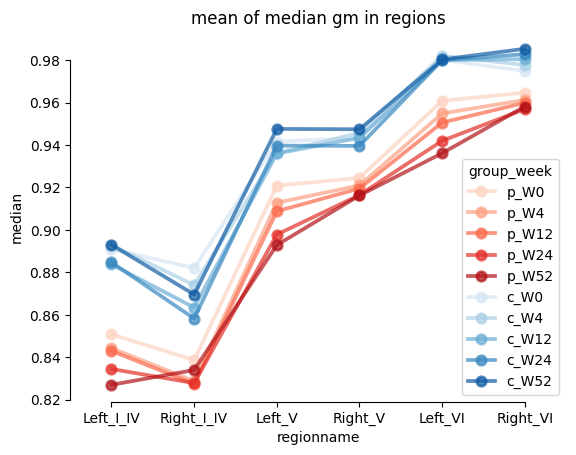

In [5]:
weeks = df_rois_GM.Week.unique()
reds = sns.color_palette("Reds", n_colors=5)
blues = sns.color_palette("Blues", n_colors=5)


df_rois_GM.loc[:,'group_week'] = df['group'].astype(str).str[0] + '_' + df['Week'].astype(str)
hue_order = [f'p_{w}' for w in weeks] + [f'c_{w}' for w in weeks]


# dictionary for colour hues of each group-week line (col by gp, hue by week); use update (dict)
palette = {}
palette.update({f'p_{w}': c for w, c in zip(weeks, reds)})
palette.update({f'c_{w}': c for w, c in zip(weeks, blues)})


sns.pointplot(data = df_rois_GM, x = 'regionname', y = 'median', hue = 'group_week', palette = palette, errorbar = 'se', alpha = 0.7)
plt.title('mean of median gm in regions')
sns.despine(trim = True)
plt.show()

/localscratch/tmp/ipykernel_84886/1879752855.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rois_WM.loc[:,'group_week'] = df['group'].astype(str).str[0] + '_' + df['Week'].astype(str)


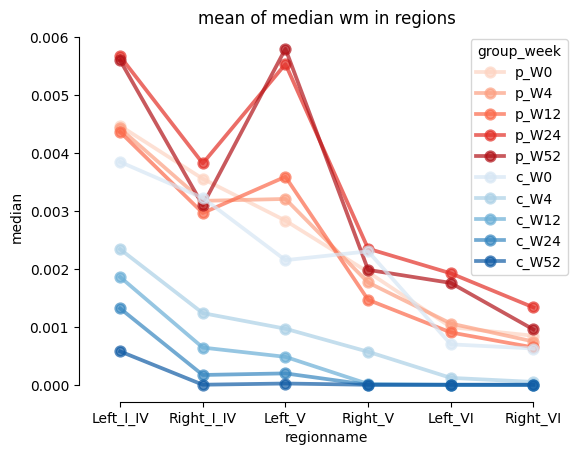

In [6]:
weeks = df_rois_WM.Week.unique()
reds = sns.color_palette("Reds", n_colors=5)
blues = sns.color_palette("Blues", n_colors=5)


df_rois_WM.loc[:,'group_week'] = df['group'].astype(str).str[0] + '_' + df['Week'].astype(str)
hue_order = [f'p_{w}' for w in weeks] + [f'c_{w}' for w in weeks]


# dictionary for colour hues of each group-week line (col by gp, hue by week); use update (dict)
palette = {}
palette.update({f'p_{w}': c for w, c in zip(weeks, reds)})
palette.update({f'c_{w}': c for w, c in zip(weeks, blues)})


sns.pointplot(data = df_rois_WM, x = 'regionname', y = 'median', hue = 'group_week', palette = palette, errorbar = 'se', alpha = 0.7)
plt.title('mean of median wm in regions')
sns.despine(trim = True)
plt.show()

/localscratch/tmp/ipykernel_84886/1088183453.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rois_CSF.loc[:,'group_week'] = df['group'].astype(str).str[0] + '_' + df['Week'].astype(str)


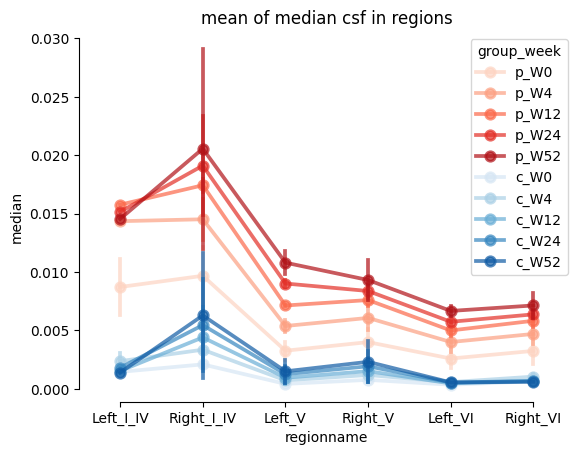

In [8]:
weeks = df_rois_CSF.Week.unique()
reds = sns.color_palette("Reds", n_colors=5)
blues = sns.color_palette("Blues", n_colors=5)


df_rois_CSF.loc[:,'group_week'] = df['group'].astype(str).str[0] + '_' + df['Week'].astype(str)
hue_order = [f'p_{w}' for w in weeks] + [f'c_{w}' for w in weeks]


# dictionary for colour hues of each group-week line (col by gp, hue by week); use update (dict)
palette = {}
palette.update({f'p_{w}': c for w, c in zip(weeks, reds)})
palette.update({f'c_{w}': c for w, c in zip(weeks, blues)})


sns.pointplot(data = df_rois_CSF, x = 'regionname', y = 'median', hue = 'group_week', palette = palette, errorbar = 'se', alpha = 0.7)
plt.title('mean of median csf in regions')
sns.despine(trim = True)
plt.show()

<Axes: xlabel='regionname', ylabel='median'>

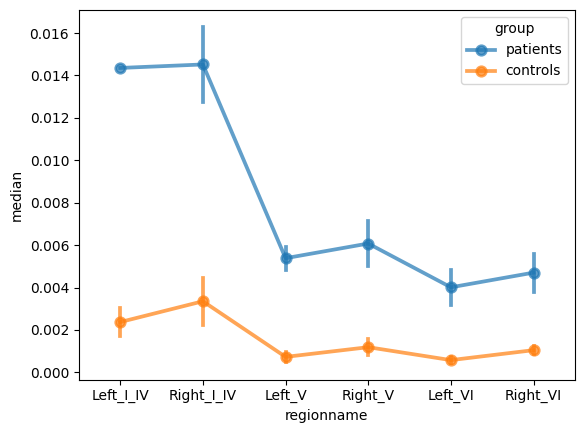

In [7]:
# WHY AREN'T THERE ERROR BARS IN CONTROLS HERE? this is with beta + se

df_rois_CSF = df[df.regionname.isin(rois) & (df.segment == 'CSF')]
sns.pointplot(data=df_rois_CSF[df_rois_CSF.Week == 'W4'], x='regionname', y='median', hue='group', errorbar='se', alpha = 0.7)